<a href="https://colab.research.google.com/github/hmd264/data-science-2026/blob/main/Pertemuan_5_Ahmad_Rilmansyah_240401010309.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



Pertemuan 5 — Visualisasi Data

Mata Kuliah: Pengantar Data Science (Kode: 200302305)
Program Studi: PJJ Informatika
Semester: 3 Dosen: Syahid Abdullah, S.Si, M.Kom

Nama : Ahmad Rilmansyah
NIM : 240401010309
Angkatan: 2024

Tujuan Notebook

Notebook ini dibuat sebagai aktivitas hands-on Pertemuan 5 untuk:

Menerapkan 5 prinsip visualisasi data yang efektif (Clarity, Accuracy, Efficiency, Aesthetics, Context)
Memilih jenis grafik yang tepat sesuai tujuan komunikasi data
Membuat bar chart, histogram, boxplot, dan scatter plot menggunakan Matplotlib & Seaborn
Menyusun dashboard visualisasi statis dari dataset Tips
Membaca grafik secara sistematis menggunakan pendekatan What? So what? Now what?

# **Import Library**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

sns.set_theme(style="whitegrid")

# **Load Dataset**

In [2]:
df = sns.load_dataset("tips")

print(df.shape)

df.head()

(244, 7)


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


In [4]:
df.describe().round(2)

,total_bill,tip,size
count,244.00,244.00,244.00
mean,19.79,3.00,2.57
std,8.90,1.38,0.95
min,3.07,1.00,1.00
25%,13.35,2.00,2.00
50%,17.80,2.90,2.00
75%,24.13,3.56,3.00
max,50.81,10.00,6.00


# **Membuat Dashboard**

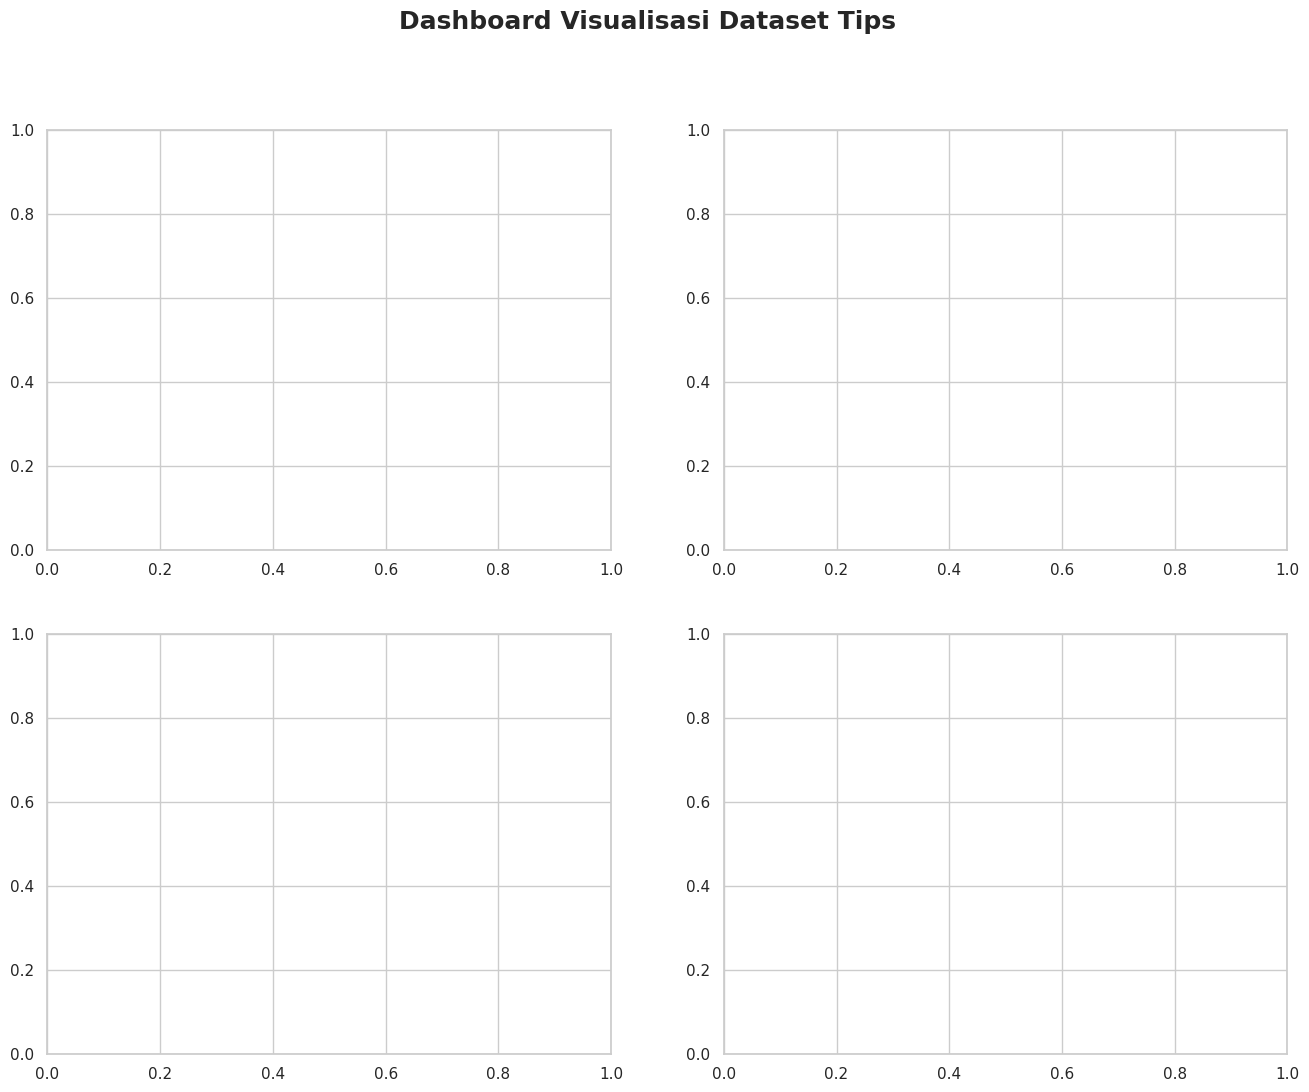

In [5]:
fig = plt.figure(figsize=(16,12))

fig.suptitle(
    "Dashboard Visualisasi Dataset Tips",
    fontsize=18,
    fontweight="bold"
)

gs = gridspec.GridSpec(2,2)

ax1 = fig.add_subplot(gs[0,0])
ax2 = fig.add_subplot(gs[0,1])
ax3 = fig.add_subplot(gs[1,0])
ax4 = fig.add_subplot(gs[1,1])

# **Grafik 1 (Bar Chart)**

In [6]:
avg_day = df.groupby("day")["total_bill"].mean()

avg_day.plot(
    kind="bar",
    color="teal",
    ax=ax1
)

ax1.set_title("Rata-rata Total Bill per Hari")
ax1.set_xlabel("Hari")
ax1.set_ylabel("USD")

/tmp/ipykernel_5534/1735701398.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_day = df.groupby("day")["total_bill"].mean()


Text(4.444444444444459, 0.5, 'USD')

What?

Grafik menunjukkan rata-rata total tagihan pelanggan pada setiap hari operasional restoran.

So what?

Terlihat bahwa Sabtu (Sat) memiliki rata-rata tagihan tertinggi, sedangkan Jumat (Fri) merupakan yang terendah. Hal ini mengindikasikan bahwa pelanggan akhir pekan cenderung melakukan transaksi dengan nilai lebih besar.

Now what?

Manajemen restoran dapat menyiapkan lebih banyak staf dan persediaan makanan pada akhir pekan untuk mengantisipasi peningkatan transaksi.

# **Grafik 2 (Histogram)**

In [7]:
sns.histplot(
    data=df,
    x="total_bill",
    hue="time",
    kde=True,
    ax=ax2
)

ax2.set_title("Distribusi Total Bill")

Text(0.5, 1.0, 'Distribusi Total Bill')

What?

Histogram menunjukkan distribusi nilai total tagihan pelanggan berdasarkan waktu makan (Lunch dan Dinner).

So what?

Sebagian besar transaksi berada pada kisaran tagihan rendah hingga menengah. Dinner memiliki jumlah transaksi lebih banyak dibanding Lunch.

Now what?

Restoran dapat memberikan promosi khusus pada waktu Lunch agar jumlah pelanggan lebih seimbang.

# **Grafik 3 (Boxplot)**

In [8]:
sns.boxplot(
    data=df,
    x="day",
    y="total_bill",
    hue="sex",
    ax=ax3
)

ax3.set_title("Total Bill Berdasarkan Hari")

Text(0.5, 1.0, 'Total Bill Berdasarkan Hari')

What?

Boxplot memperlihatkan distribusi total tagihan berdasarkan hari dan jenis kelamin pelanggan.

So what?

Terlihat adanya beberapa outlier, yaitu pelanggan dengan nilai transaksi jauh lebih tinggi dibanding pelanggan lainnya.

Now what?

Restoran dapat menganalisis karakteristik pelanggan dengan transaksi tinggi untuk menyusun strategi pemasaran yang lebih tepat sasaran.

# **Grafik 4 (Scatter Plot)**

In [9]:
sns.scatterplot(
    data=df,
    x="total_bill",
    y="tip",
    hue="time",
    size="size",
    sizes=(40,200),
    alpha=0.7,
    ax=ax4
)

sns.regplot(
    data=df,
    x="total_bill",
    y="tip",
    scatter=False,
    color="red",
    ax=ax4
)

ax4.set_title("Hubungan Total Bill dan Tip")

Text(0.5, 1.0, 'Hubungan Total Bill dan Tip')

What?

Scatter plot menunjukkan hubungan antara total tagihan dengan tip yang diberikan pelanggan.

So what?

Semakin besar total tagihan, semakin besar pula tip yang diberikan. Garis regresi memperlihatkan hubungan positif antara kedua variabel.

Now what?

Restoran dapat meningkatkan nilai transaksi pelanggan melalui paket menu atau promosi karena kenaikan transaksi juga berpotensi meningkatkan tip yang diterima pelayan.

# **Simpan Dashboard**

In [10]:
plt.tight_layout()

plt.savefig(
    "dashboard_tips.png",
    dpi=150
)

plt.show()

<Figure size 640x480 with 0 Axes>

# **Kesimpulan**

Berdasarkan hasil visualisasi menggunakan dataset Tips, diperoleh beberapa insight penting.

1. Hari Sabtu memiliki rata-rata total tagihan tertinggi.
2. Dinner merupakan waktu makan dengan jumlah transaksi lebih banyak dibanding Lunch.
3. Terdapat beberapa pelanggan dengan transaksi sangat tinggi (outlier).
4. Total Bill memiliki hubungan positif dengan Tip yang diberikan pelanggan.

Visualisasi ini membantu memahami pola transaksi pelanggan sehingga dapat digunakan sebagai dasar pengambilan keputusan bisnis, seperti pengaturan jadwal karyawan, strategi promosi, dan peningkatan pelayanan restoran.